<a href="https://colab.research.google.com/github/zillioxmatthewprojects-ops/Bus_Route_ML/blob/main/Bus_Route_Data_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load Bus Data, Fare Price sheet, and libraries. Test load works.


In [1]:
#Created by Matt Z
#Starting Line up
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from itertools import combinations


#import Cleaned bus data
df = pd.read_csv(r"/content/Bus Depot ML2_data.csv")
print("Jumanji 1: Bus Data Loaded")

#import Price Sheet
df_Fare = pd.read_excel(r"/content/Bus ML Fare list.xlsx")
print("Jumanji 2: Bus Price Sheet Data Loaded")
df.info()
df_Fare.head()

Jumanji 1: Bus Data Loaded
Jumanji 2: Bus Price Sheet Data Loaded
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   TripID       25000 non-null  object
 1   TripDate     25000 non-null  object
 2   State        25000 non-null  object
 3   RouteName    25000 non-null  object
 4   VehicleType  25000 non-null  object
 5   Ridership    25000 non-null  int64 
dtypes: int64(1), object(5)
memory usage: 1.1+ MB


,VehicleType,Capacity,Fare,Trip Cost,Break-even riders
0,Mini,35,3.0,70,24
1,Standard,70,3.0,110,37
2,Volt,85,2.5,80,32
3,HellCat,105,2.0,120,60


Add fare sheet to dataset, add calculated columns for Revenue, Profit, and Binary profit column.
Add date info columns for ML.

In [2]:
#add price sheet dataset to main df with merge to create 3 columns with data based on Vehicle and VehicleType
lookup_df = pd.DataFrame(df_Fare, columns=['VehicleType', 'Capacity', 'Fare', 'Trip Cost', 'Break-even riders'])
df = df.merge(
    lookup_df,
    left_on='VehicleType',
    right_on='VehicleType',
    how='left'
)
print("Jumanji 1: Merg Complete\n")

#add new revenue column from trip cost * ridership
df['Trip Revenue'] = df['Fare'] * df['Ridership']
print("Jumanji 2: Add Revenue Complete\n")

#add new profit column from trip revenue - trip cost
df['Trip Profit'] = df['Trip Revenue'] - df['Trip Cost']
print("Jumanji 3: Add Profit Complete\n")
df.head()

#Add Binary column is this ride profitable (Ridership > Break-even Riders)
df['Profitable Trip'] = np.where(df['Ridership'] > (df['Break-even riders']+1), 'Yes', 'No')

#add trip date info columns
df['TripDate'] = pd.to_datetime(df['TripDate'])
df['Month_num'] = df['TripDate'].dt.month
df.head()

Jumanji 1: Merg Complete

Jumanji 2: Add Revenue Complete

Jumanji 3: Add Profit Complete



,TripID,TripDate,State,RouteName,VehicleType,Ridership,Capacity,Fare,Trip Cost,Break-even riders,Trip Revenue,Trip Profit,Profitable Trip,Month_num
0,TRIP-16868,2023-02-12,New York,Route 6,Standard,29,70,3.0,110,37,87.0,-23.0,No,2
1,TRIP-34016,2023-10-04,New York,Route 5,Mini,27,35,3.0,70,24,81.0,11.0,Yes,10
2,TRIP-19668,2023-07-14,California,Route 1,Standard,40,70,3.0,110,37,120.0,10.0,Yes,7
3,TRIP-23640,2023-09-08,California,Route 1,Volt,47,85,2.5,80,32,117.5,37.5,Yes,9
4,TRIP-24018,2022-07-24,Texas,Route 3,HellCat,26,105,2.0,120,60,52.0,-68.0,No,7


Check dataset for unique categories and data formatting, duplicate rows, missing values, display columns with missing values, and numerical column summary.

In [3]:
#Data check for issues
#1 Check for cateogrical issues
for col in df:
  print(f"{col}: {df[col].dropna().unique()[:15]} \n")

#2 check for duplicates
duplicate_count = df.duplicated().sum()
print(f"Duplicates: {duplicate_count}\n")

#3 Count of missing values per column
missing_summary = df.isnull().sum()

# Display only columns that actually have missing values and %
print("Columns With Missing Values:")
print(missing_summary[missing_summary > 0])
print()

#4 Numeric variable summary statistics
print("Numeric Statistics")
df.describe().style.format("{:,.0f}")

TripID: ['TRIP-16868' 'TRIP-34016' 'TRIP-19668' 'TRIP-23640' 'TRIP-24018'
 'TRIP-17488' 'TRIP-15804' 'TRIP-22909' 'TRIP-13386' 'TRIP-19567'
 'TRIP-31423' 'TRIP-13503' 'TRIP-16657' 'TRIP-29192' 'TRIP-12518'] 

TripDate: <DatetimeArray>
['2023-02-12 00:00:00', '2023-10-04 00:00:00', '2023-07-14 00:00:00',
 '2023-09-08 00:00:00', '2022-07-24 00:00:00', '2025-06-13 00:00:00',
 '2023-02-14 00:00:00', '2022-02-03 00:00:00', '2022-12-31 00:00:00',
 '2023-10-24 00:00:00', '2025-08-29 00:00:00', '2023-02-09 00:00:00',
 '2022-12-18 00:00:00', '2022-03-09 00:00:00', '2024-09-29 00:00:00']
Length: 15, dtype: datetime64[ns] 

State: ['New York' 'California' 'Texas' 'Maryland' 'Florida' 'Colorado'] 

RouteName: ['Route 6' 'Route 5' 'Route 1' 'Route 3' 'Route 2' 'Route 4' 'Route 8'
 'Route 7' 'Route 9'] 

VehicleType: ['Standard' 'Mini' 'Volt' 'HellCat'] 

Ridership: [29 27 40 47 26 33 84 54 14 51 35 18 65 23 52] 

Capacity: [ 70  35  85 105] 

Fare: [3.  2.5 2. ] 

Trip Cost: [110  70  80 120] 

Bre

,TripDate,Ridership,Capacity,Fare,Trip Cost,Break-even riders,Trip Revenue,Trip Profit,Month_num
count,"25,000","25,000","25,000","25,000","25,000","25,000","25,000","25,000","25,000"
mean,",.0f",37,70,3,97,38,93,-4,7
min,",.0f",0,35,2,70,24,0,-120,1
25%,",.0f",19,35,2,70,24,54,-32,4
50%,",.0f",33,70,3,110,37,87,-8,6
75%,",.0f",51,105,3,120,60,129,22,10
max,",.0f",105,105,3,120,60,212,132,12
std,nan,22,26,0,21,14,49,43,3


Define and compare categorical values and crosstab each.

In [4]:
#Determine categorical distibution
categorical_cols = ['VehicleType', 'RouteName', 'State', 'Profitable Trip']

#print counts of each categorical col
print("Jumanji 1: Categorical Distribution")
for col in categorical_cols:
    print(df[col].value_counts())
    print()

print("\nJumanji 2: Categorical Comparison")
#compare each categorical col
for col1, col2 in combinations(categorical_cols, 2):
    print(f"\n--- {col1} vs {col2} ---")
    print(pd.crosstab(df[col1], df[col2]))

Jumanji 1: Categorical Distribution
VehicleType
Standard    8340
Mini        7420
HellCat     6268
Volt        2972
Name: count, dtype: int64

RouteName
Route 1    4025
Route 7    3676
Route 3    3530
Route 5    2987
Route 9    2524
Route 6    2282
Route 2    2254
Route 8    2027
Route 4    1695
Name: count, dtype: int64

State
California    6279
New York      5269
Texas         5225
Florida       3676
Colorado      2524
Maryland      2027
Name: count, dtype: int64

Profitable Trip
No     15632
Yes     9368
Name: count, dtype: int64


Jumanji 2: Categorical Comparison

--- VehicleType vs RouteName ---
RouteName    Route 1  Route 2  Route 3  Route 4  Route 5  Route 6  Route 7  \
VehicleType                                                                  
HellCat         1372      545      518      259     1010      830      564   
Mini             378      661     1796      853      295      222     1835   
Standard        1680      815      855      425     1195      901      910   
V

Visualize categorical values individually.

Visualization for VehicleType


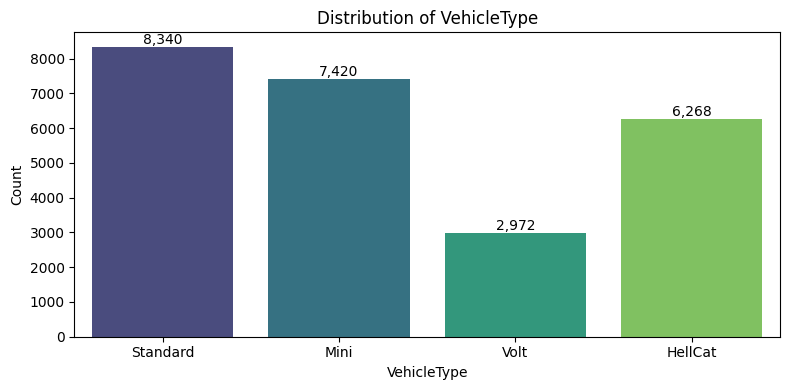


Visualization for RouteName


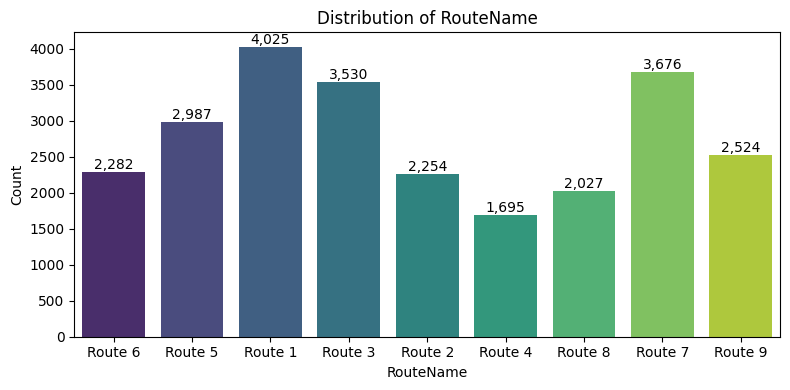


Visualization for State


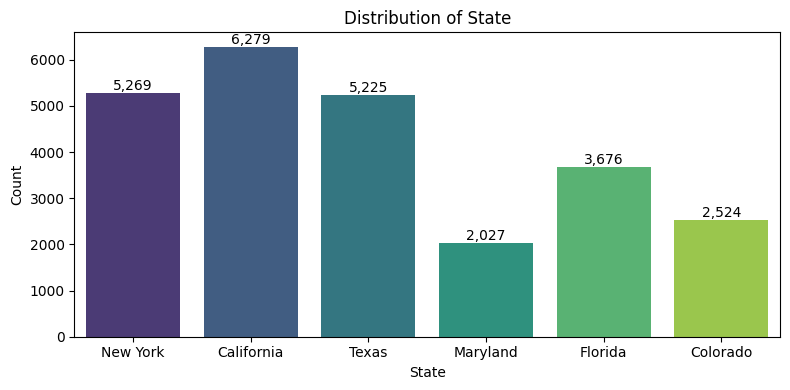


Visualization for Profitable Trip


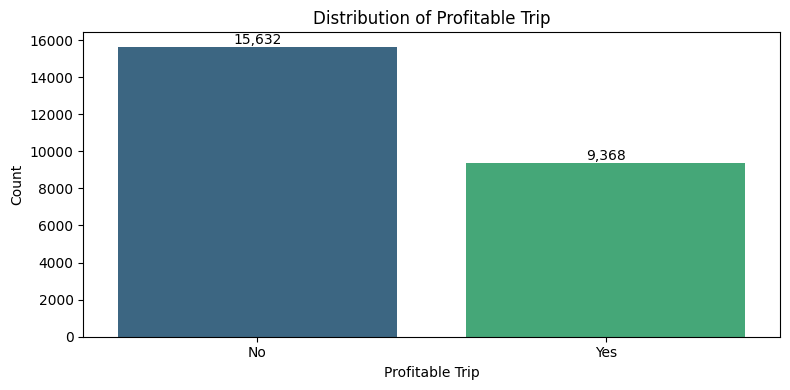

In [5]:
for var in categorical_cols:
    print(f"Visualization for {var}")
    plt.figure(figsize=(8, 4))
    ax = sns.countplot(data=df, x=var, hue=var, legend=False, palette='viridis')
    # each hue-split bar is its own container, so label all of them
    for container in ax.containers:
      ax.bar_label(container, fmt='{:,.0f}')
    plt.title(f'Distribution of {var}')
    plt.xlabel(var)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
    print()

Visualize categorical comparisons.

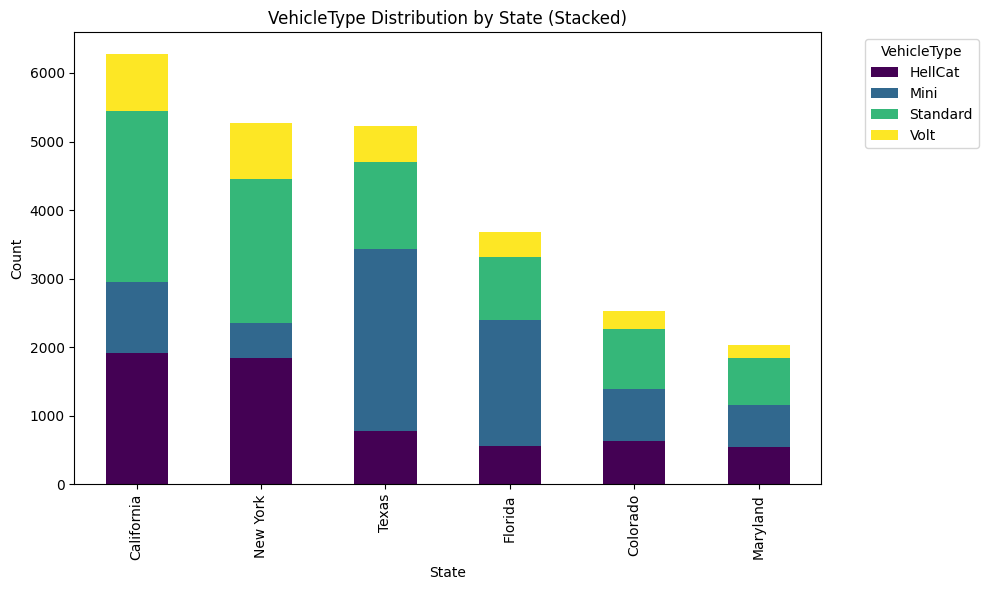

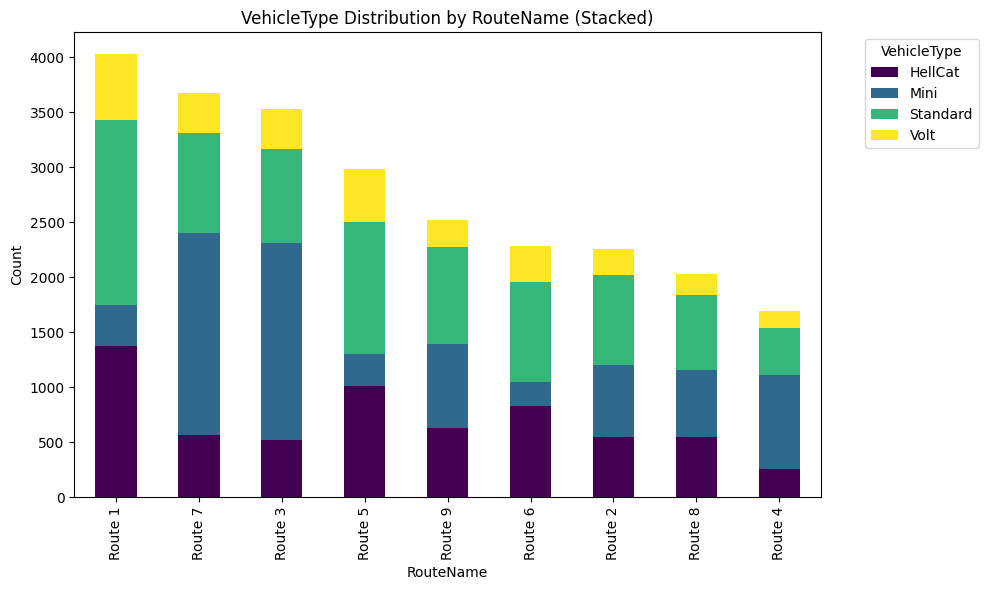

In [6]:
#Visuals of categorical comparisons

# Stacked bar: VehicleType breakdown within each State
state_vehicle = pd.crosstab(df['State'], df['VehicleType'])
state_vehicle = state_vehicle.loc[state_vehicle.sum(axis=1).sort_values(ascending=False).index]  # order States by total count
ax = state_vehicle.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('VehicleType Distribution by State (Stacked)')
plt.xlabel('State')
plt.ylabel('Count')
plt.legend(title='VehicleType', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print()
# Stacked bar: VehicleType breakdown within each RouteName
route_vehicle = pd.crosstab(df['RouteName'], df['VehicleType'])
route_vehicle = route_vehicle.loc[route_vehicle.sum(axis=1).sort_values(ascending=False).index]  # order Routes by total count

ax = route_vehicle.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('VehicleType Distribution by RouteName (Stacked)')
plt.xlabel('RouteName')
plt.ylabel('Count')
plt.legend(title='VehicleType', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Check which trips are not profitable with visual

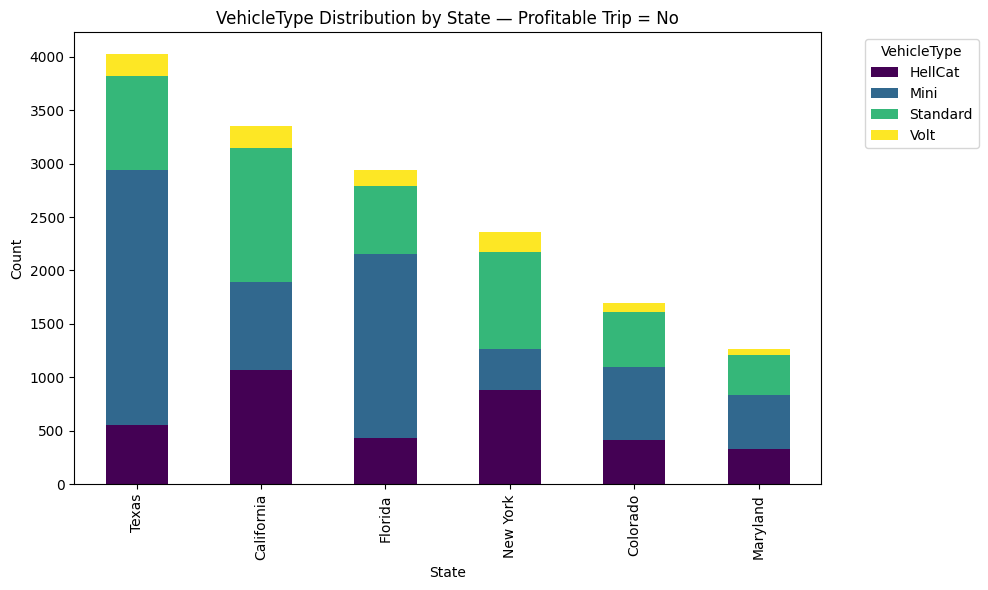

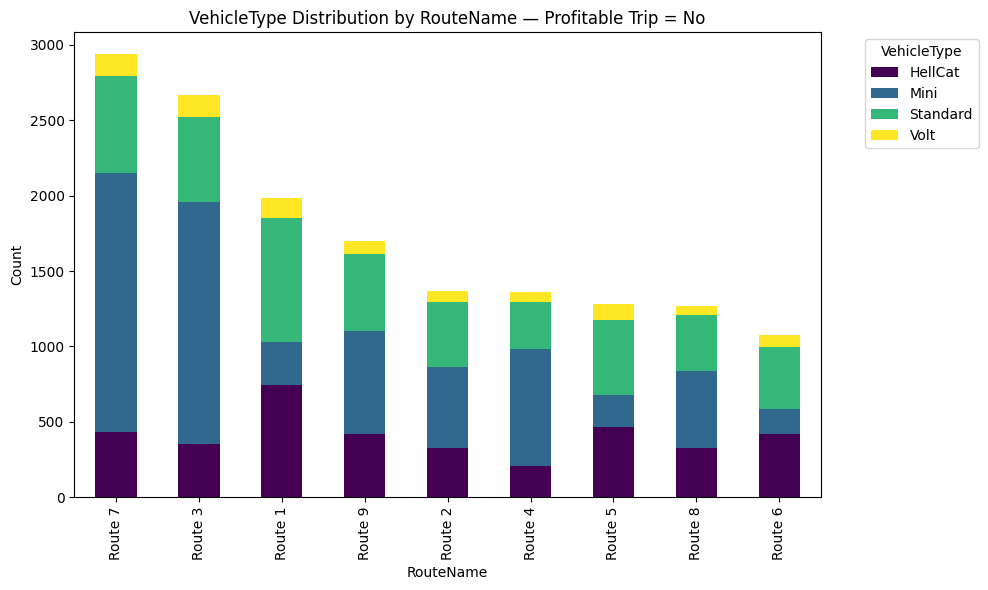

In [7]:
# Stacked bar: VehicleType breakdown within each State, split by profitability
for status in ['No']:
    subset = df[df['Profitable Trip'] == status]
    state_vehicle = pd.crosstab(subset['State'], subset['VehicleType'])
    state_vehicle = state_vehicle.loc[state_vehicle.sum(axis=1).sort_values(ascending=False).index]  # order States by total count

    ax = state_vehicle.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
    plt.title(f'VehicleType Distribution by State — Profitable Trip = {status}')
    plt.xlabel('State')
    plt.ylabel('Count')
    plt.legend(title='VehicleType', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

print()
# Stacked bar: VehicleType breakdown within each RouteName, split by profitability
for status in ['No']:
    subset = df[df['Profitable Trip'] == status]
    route_vehicle = pd.crosstab(subset['RouteName'], subset['VehicleType'])
    route_vehicle = route_vehicle.loc[route_vehicle.sum(axis=1).sort_values(ascending=False).index]  # order Routes by total count

    ax = route_vehicle.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
    plt.title(f'VehicleType Distribution by RouteName — Profitable Trip = {status}')
    plt.xlabel('RouteName')
    plt.ylabel('Count')
    plt.legend(title='VehicleType', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

Test capabilities of charting to show visual complexity.

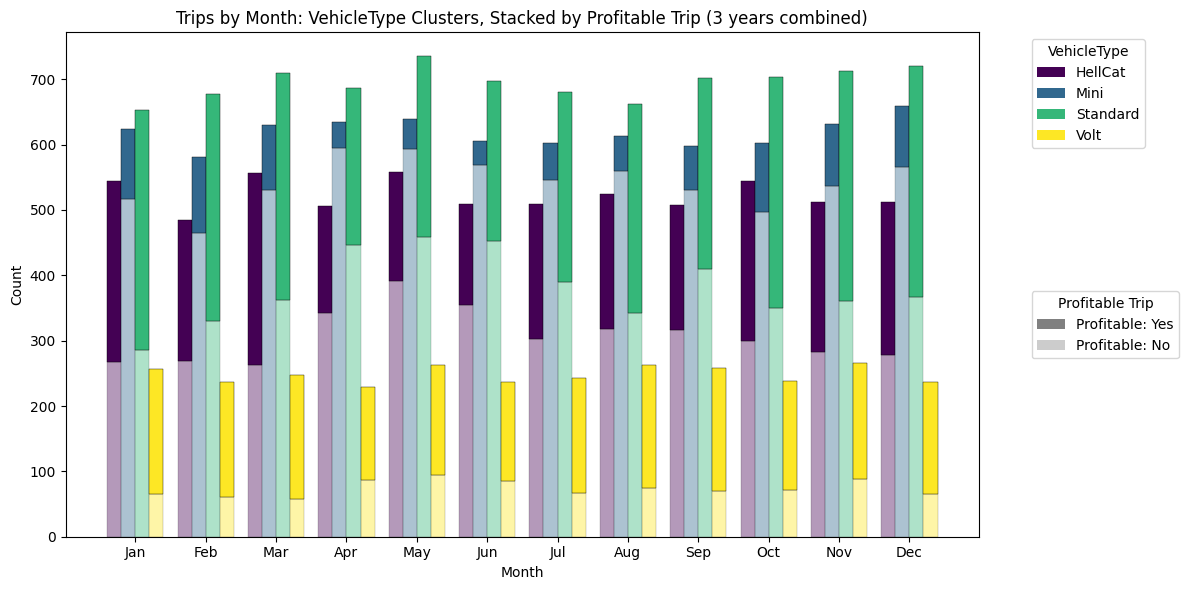

In [8]:
# Ensure TripDate is a real datetime, then pull out the month number (1-12) to   sort Jan->Dec
#Testing capabilities of charting, seems to busy for usage.


# Count trips by Month, VehicleType, and Profitable Trip (combining all 3 years into each month)
grouped = df.groupby(['Month_num', 'VehicleType', 'Profitable Trip']).size().reset_index(name='Count')

vehicle_types = sorted(df['VehicleType'].unique())
months = range(1, 13)  # Jan(1) through Dec(12)
month_labels = [pd.Timestamp(2020, m, 1).strftime('%b') for m in months]  # 'Jan', 'Feb', ...

# Pivot into Month x VehicleType tables, one for 'No' counts and one for 'Yes' counts, filling gaps with 0
no_counts = grouped[grouped['Profitable Trip'] == 'No'].pivot(index='Month_num', columns='VehicleType', values='Count').reindex(index=months, columns=vehicle_types).fillna(0)
yes_counts = grouped[grouped['Profitable Trip'] == 'Yes'].pivot(index='Month_num', columns='VehicleType', values='Count').reindex(index=months, columns=vehicle_types).fillna(0)

# --- Manual grouped + stacked bar chart ---
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(months))              # base x position for each month
n_vehicles = len(vehicle_types)
bar_width = 0.8 / n_vehicles             # total cluster width 0.8, split across vehicle types

colors = plt.cm.viridis(np.linspace(0, 1, n_vehicles))  # one base color per VehicleType

for i, vt in enumerate(vehicle_types):
    offset = (i - n_vehicles / 2) * bar_width + bar_width / 2
    # 'No' segment: bottom of the stack, drawn with lower alpha (lighter) so it reads as "No"
    ax.bar(x + offset, no_counts[vt], bar_width, bottom=0,
           color=colors[i], alpha=0.4, edgecolor='black', linewidth=0.3)
    # 'Yes' segment: stacked on top of 'No', full opacity so it reads as "Yes"
    ax.bar(x + offset, yes_counts[vt], bar_width, bottom=no_counts[vt],
           color=colors[i], alpha=1.0, edgecolor='black', linewidth=0.3)

ax.set_xticks(x)
ax.set_xticklabels(month_labels)
ax.set_xlabel('Month')
ax.set_ylabel('Count')
ax.set_title('Trips by Month: VehicleType Clusters, Stacked by Profitable Trip (3 years combined)')


# Custom legend: one color swatch per VehicleType, plus a separate Yes/No opacity key
from matplotlib.patches import Patch
vehicle_legend = [Patch(facecolor=colors[i], label=vt) for i, vt in enumerate(vehicle_types)]
status_legend = [Patch(facecolor='gray', alpha=1.0, label='Profitable: Yes'),
                  Patch(facecolor='gray', alpha=0.4, label='Profitable: No')]
first_legend = ax.legend(handles=vehicle_legend, title='VehicleType', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.add_artist(first_legend)  # add_artist keeps this legend visible after the second .legend() call replaces the default one
ax.legend(handles=status_legend, title='Profitable Trip', bbox_to_anchor=(1.05, 0.5), loc='upper left')

plt.tight_layout()
plt.show()